![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 2.0. Coupler Design

## 0. Imports 

### 0.1. General libraries

In [7]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength


### 0.2. Functions by us

In [2]:
from upvfab_design_tools import MMI_EME, DC_EME

In [3]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Directional coupler length and coupling coefficient

The total power transferred to the output is modeled using the coupling coefficient (K). This coefficient depends on the relationship between the physical length of the coupling region and the beating length:

<img src="k.png" alt="Coupling Coefficient Equation" width="400">

Simulate a directional coupler that implements two deep waveguide cores of 1.2 microns width and with a gap of 600 nm between them. 
- Plot the transfer function: K vs L/Lpi
- Comment the results: distance needed for a complete energy transfer between waveguides, distance needed for splitting power in half.. 

2026-03-10 12:39:06.008 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\WaveguideCoupler_e9d8970c9a30f0a4.npz.
Longitud de Batido TE: 118.67323659888964 um
Longitud de Batido TM: 60.86489511697812 um


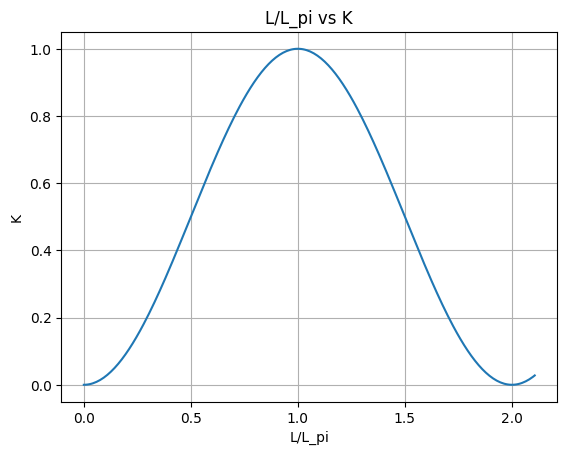

In [4]:
lambda_c = 1.5

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(1.2, 1.2), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600 * nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_neff = dcoupler_cs.n_eff
#print(f'Índices efectivos: {dcoupler_neff}')

te_frac = dcoupler_cs.fraction_te
#print(f'Fracción TE: {te_frac}')

L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(f'Longitud de Batido TE: {L_pi_TE} um')

L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
print(f'Longitud de Batido TM: {L_pi_TM} um')

L = np.linspace(0, 250, 250)

K = np.array(250)
for i in range(250): 
    K= np.sin((1/2)*np.pi*(L/L_pi_TE))**2

plt.plot(L/L_pi_TE, K)
plt.title('L/L_pi vs K')
plt.xlabel('L/L_pi')
plt.ylabel('K')
plt.grid()
plt.show()

## LO.2. 2x2 Directional Coupler

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [77]:
# Simulation flow for Directional Couplers
# Define your geometrical parameters here
wg_gap = 0.6 # Student. Gap between waveguides
wg_width = 1.2 # Student. Core waveguides width

d = wg_width + wg_gap
wg_N = 2


m = DC_EME() # Here you instantiate a Directional Coupler to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_num_modes = 12 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 
m.DC_wg_gap = wg_gap # Gap between waveguides
m.DC_wg_width = wg_width # Width of the waveguides core
m.DC_N_waveguides = wg_N

# 1) Compute de DC modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  94.02742605178902  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/940 [00:00<?, ?it/s]

------- Pameters -------
MMI length 47.0137
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9688
Total OUT power: 0.9583
Excess loss [dB] =  0.1851
------------------------
Power over OUTs:  ['0.4791', '0.4791']
Ratio over OUTs ['0.5000', '0.5000']


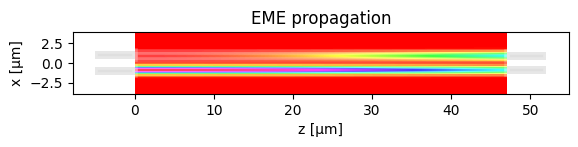

In [78]:
# IMPORTANT!!! 
# # If you DON'T change any geometrical parameter
# (waveguide widths or gap) you can skip last cell. 
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure DC
# DC I/O number
m.n_IN = 2
m.n_OUT = 2


m.L_MMI = (1/2)*L_pi # Since we use the same library for propagation simulations of MMI and DC 
                    # some variables might be identified as "MMI". Sorry about that (: 
                    # Might change in the future 

# 4) Run propagation - get power transfer and plot propagation
m.propagation()

c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  128.0656733391699  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1281 [00:00<?, ?it/s]

------- Pameters -------
MMI length 64.0328
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9841
Total OUT power: 0.9737
Excess loss [dB] =  0.1157
------------------------
Power over OUTs:  ['0.4869', '0.4868']
Ratio over OUTs ['0.5000', '0.5000']


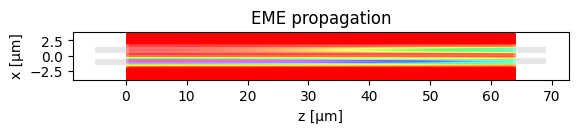

In [81]:
wg_gap = 0.7
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  173.96389977140092  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/1740 [00:00<?, ?it/s]

------- Pameters -------
MMI length 86.9819
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9882
Total OUT power: 0.9778
Excess loss [dB] =  0.0976
------------------------
Power over OUTs:  ['0.4888', '0.4890']
Ratio over OUTs ['0.4999', '0.5001']


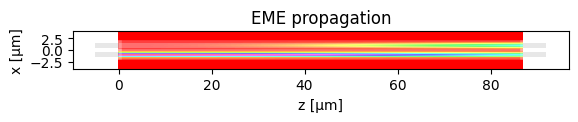

In [83]:
wg_gap = 0.8
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  235.77407047793963  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2358 [00:00<?, ?it/s]

------- Pameters -------
MMI length 117.8870
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9832
Total OUT power: 0.9728
Excess loss [dB] =  0.1198
------------------------
Power over OUTs:  ['0.4863', '0.4865']
Ratio over OUTs ['0.4999', '0.5001']


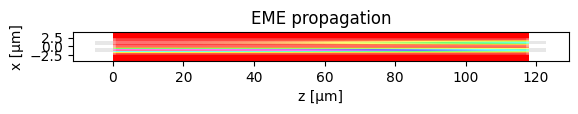

In [84]:
wg_gap = 0.9
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI =0.5* L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  318.884152076578  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/3189 [00:00<?, ?it/s]

------- Pameters -------
MMI length 159.4421
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9663
Total OUT power: 0.9560
Excess loss [dB] =  0.1955
------------------------
Power over OUTs:  ['0.4778', '0.4782']
Ratio over OUTs ['0.4998', '0.5002']


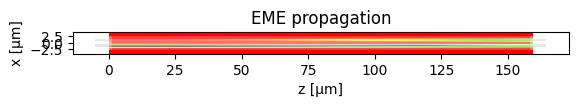

In [85]:
wg_gap = 1
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5* L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  430.5476100761713  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/4305 [00:00<?, ?it/s]

------- Pameters -------
MMI length 215.2738
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9360
Total OUT power: 0.9258
Excess loss [dB] =  0.3351
------------------------
Power over OUTs:  ['0.4628', '0.4629']
Ratio over OUTs ['0.4999', '0.5001']


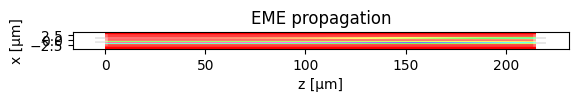

In [86]:
wg_gap = 1.1
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5* L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  580.4293623078369  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/5804 [00:00<?, ?it/s]

------- Pameters -------
MMI length 290.2147
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8916
Total OUT power: 0.8818
Excess loss [dB] =  0.5464
------------------------
Power over OUTs:  ['0.4407', '0.4410']
Ratio over OUTs ['0.4998', '0.5002']


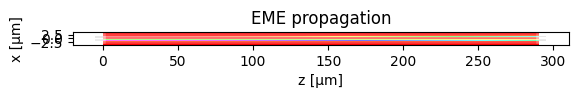

In [87]:
wg_gap = 1.2
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5 *L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  781.3901391728815  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/7814 [00:00<?, ?it/s]

------- Pameters -------
MMI length 390.6951
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.8474
Total OUT power: 0.8380
Excess loss [dB] =  0.7677
------------------------
Power over OUTs:  ['0.4189', '0.4191']
Ratio over OUTs ['0.4999', '0.5001']


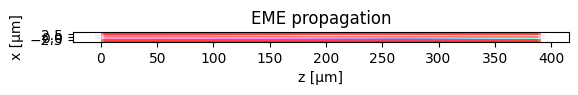

In [88]:
wg_gap = 1.3
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI =0.5* L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  1050.4786848602807  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10505 [00:00<?, ?it/s]

------- Pameters -------
MMI length 525.2393
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7870
Total OUT power: 0.7782
Excess loss [dB] =  1.0893
------------------------
Power over OUTs:  ['0.3889', '0.3893']
Ratio over OUTs ['0.4997', '0.5003']


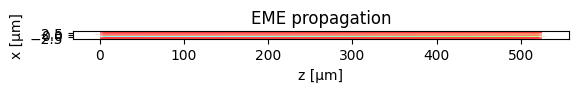

In [89]:
wg_gap = 1.4
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*L_pi
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1410.660712377105  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/14107 [00:00<?, ?it/s]

------- Pameters -------
MMI length 705.3304
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.7299
Total OUT power: 0.7217
Excess loss [dB] =  1.4167
------------------------
Power over OUTs:  ['0.3607', '0.3609']
Ratio over OUTs ['0.4999', '0.5001']


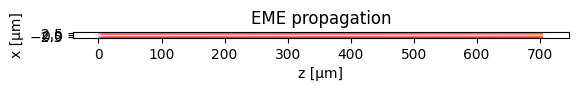

In [91]:
wg_gap = 1.5
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
m.propagation() 


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  -1892.4674124081394  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/18925 [00:00<?, ?it/s]

------- Pameters -------
MMI length 946.2337
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.6724
Total OUT power: 0.6648
Excess loss [dB] =  1.7729
------------------------
Power over OUTs:  ['0.3327', '0.3321']
Ratio over OUTs ['0.5004', '0.4996']


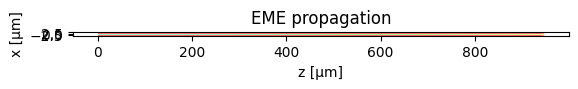

In [93]:
wg_gap = 1.6
m = DC_EME()
m.MMI_num_modes = 12
m.DC_wg_gap = wg_gap
m.DC_wg_width = wg_width
m.DC_N_waveguides = wg_N
m.find_all_modes() 
L_pi = m.get_L_pi()

print("L_pi = ", L_pi, " µm")

m.n_IN = 2
m.n_OUT = 2

m.L_MMI = 0.5*np.abs(L_pi)
m.propagation() 


## LO.3. Parallel uncoupled waveguide

c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real dis

Text(0.5, 1.0, 'Gap vs K')

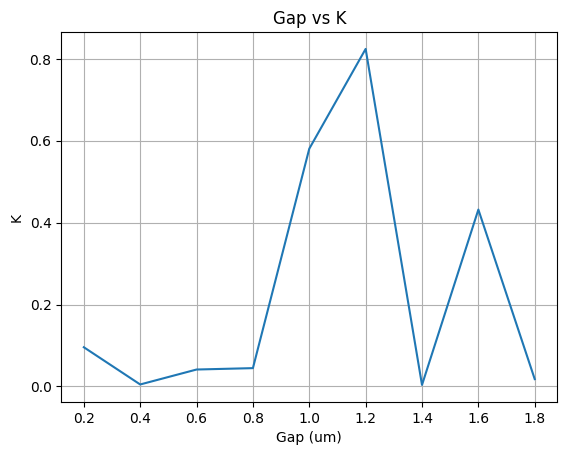

In [9]:
wg_width = 1
L = 10*1000

gaps = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8]
L_pi = []
K = []

for g in gaps: 
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = g
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2

    m.find_all_modes()

    Lpi= m.get_L_pi()
    L_pi.append(Lpi)

    K_0 = np.sin(0.5*np.pi*(L/Lpi))**2
    K.append(K_0)

plt.plot(gaps, K)
plt.grid()
plt.xlabel('Gap (um)')
plt.ylabel('K')
plt.title('Gap vs K')

In [8]:
wg_width = 1
L = 10*1000    

gaps = [0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
L_pi = []
K = []

for g in gaps: 
    m = DC_EME()
    m.MMI_num_modes = 12
    m.DC_wg_gap = g
    m.DC_wg_width = wg_width
    m.DC_N_waveguides = 2

    
    # ---------------------------
    m.mat_core  = mat.shallow_sin(1.55)
    m.mat_cladd = mat.sio2(1.55)

    m.find_all_modes()

    Lpi = m.get_L_pi()
    L_pi.append(Lpi)

    K_0 = np.sin(0.5 * np.pi * (L / Lpi))**2
    K.append(K_0)

plt.plot(gaps, K)
plt.grid()
plt.xlabel('Gap (um)')
plt.ylabel('K')
plt.title('Gap vs K (SHALLOW)')

AttributeError: module 'gplugins.tidy3d.materials' has no attribute 'shallow_sin'

In [ ]:
# HINT. Calculate manually the L_pi you may need to achieve K=0.1
# Then you can sweep the gap and calculate the L_pi until reaching 
# the desired value. 

## LO.4. 2x2 Multimode Interference Coupler

### LO.4.1 Propagation Simulation

For the multimode interference (MMI) couplers we must rely on the design tables shown on the theoretical session: 

<img src="mmi.png" alt="Design tables for MMI couplers" width="600">

Here, you will use some functions provided by us (check **0. Imports** for more details) to simulate the propagation in a 2x2 directional coupler. Please read all the comments in the following code carefully and **make changes only to the lines marked with the #Student tag**

In [21]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 6.6 # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.MMI_num_modes = 20 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.find_all_modes()

# 2) Get the L_pi 
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607256824  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/690 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment 0.0000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9604
Total OUT power: 0.9075
Excess loss [dB] =  0.4217
------------------------
Power over OUTs:  ['0.4675', '0.4399']
Ratio over OUTs ['0.5152', '0.4848']


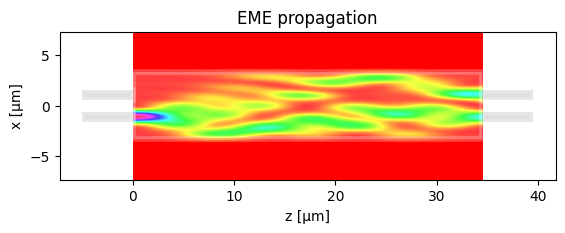

In [23]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT
m.dL_MMI = 0
dy = 0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6]) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6])# STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi # STUDENT

# Run propagation
m.propagation()

### LO.4.2. 2x2 Multimode Interference Coupler - Optimization

  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9571
Total OUT power: 0.9149
Excess loss [dB] =  0.3861
------------------------
Power over OUTs:  ['0.4631', '0.4518']
Ratio over OUTs ['0.5062', '0.4938']


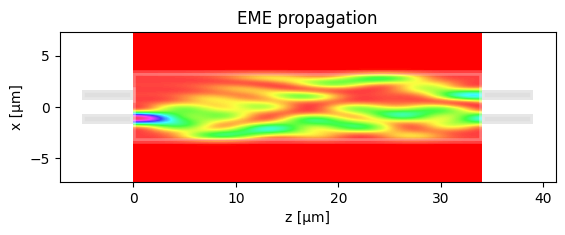

In [24]:
dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*(np.array([-1/6, 1/6])) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = mmi_Width*(np.array([-1/6, 1/6])) + np.array([-dy, dy]) # STUDENT

# MMI length (check class slides for type of MMI)
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

### LO.4.3 2x2 Multimode Interference Coupler – Optimization (II)

In [25]:
# Design flow for MMI

m = MMI_EME()
m.MMI_width = 6.6   # MMI width
m.wg_width_dw = 1.2 # STUDENT

# 1) Compute de MMI modes
m.find_all_modes()

# 2) Get the L_pi
L_pi = m.get_L_pi()
print("L_pi = ", L_pi, " µm")

c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


L_pi =  69.03598607257643  µm


c:\Users\María Romero García\Documents\UNI\PIC MÁSTER\diseño\lab 2\pic-upv-lab2\.venv\Lib\site-packages\skfem\assembly\form\linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/680 [00:00<?, ?it/s]

------- Pameters -------
MMI length 34.5180
MMI length increment -0.5000
IO wg width 1.0000
IO wg width increment 1.2000
------------------------
Total power IN coupled 0.9991
Total OUT power: 0.8521
Excess loss [dB] =  0.6951
------------------------
Power over OUTs:  ['0.4096', '0.4425']
Ratio over OUTs ['0.4807', '0.5193']


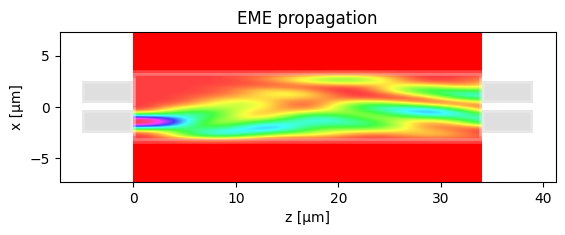

In [26]:
# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)
m.n_IN = 2 # STUDENT
m.n_OUT = 2 # STUDENT

dy = 0.05
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = mmi_Width*np.array([-1/6, 1/6] + np.array([-dy, dy])) # STUDENT
m.OUT_WVG_positions = mmi_Width*np.array([-1/6, 1/6] + np.array([-dy, dy])) # STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = (1/2)*L_pi  # STUDENT
m.dL_MMI = -0.5 # STUDENT

# Run propagation
m.propagation()

## LO.5. 1x4 1x4 Multimode Interference Coupler 

Repeat the design procedure explained for the 2x2 Coupler to design a 1x4 MMI Coupler. Consider: 
- Select a suitable MMI body width, taking into account that you now must allocate 4 waveguides at the output. 
- Minimize the losses and output imbalance for the MMI coupler. 

## Extra - Exercises

### E1. Directional coupler gap dependence

In [ ]:
gap_to_simulate = 600 * nm # STUDENT. You can manually change the gap
                            # or you can sweep the parameter using a Python for loop. 

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=gap_to_simulate,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

# STUDENT. Plot goes here


### E2. Directional coupler wavelength dependence

In [ ]:
wavelength = ... # STUDENT code goes here

deep_dcoupler_cs = gt.modes.WaveguideCoupler(
    wavelength=wavelength, # Wavelength to simulate - Must be a vector
    core_width=(1.0, 1.0), # Waveguide width
    gap=600 * nm,
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    core_thickness=300 * nm, # Waveguide height 
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

deep_neff = deep_dcoupler_cs.n_eff
L_pi_TE = ... # STUDENT code here

plt.figure(figsize=(10, 5))
plt.scatter(wavelength, L_pi_TE,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(wavelength, L_pi_TE,label='Deep')
plt.xlabel("Wavelength (um)")
plt.ylabel("L_pi")
plt.grid()
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

### E3. MMI coupler wavelength dependence

In [ ]:
mmi_body_w = 6.6 
lambda_c = ... # STUDENT code goes here.

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 

### E4. MMI coupler body width dependence

In [ ]:
lambda_c = 1.55

mmi_body_w = 6.6 # STUDENT. You can manually change the body width
                 # or you can sweep the parameter using a Python for loop. 

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=15, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = ... # STUDENT code goes here

# STUDENT plot here. 